#### &#128187; Coding starts here

The first code cell loads the Python libraries and you can continue with your code by adding more cells below.

In [1]:
# reads the .nc and .nc4 files
import netCDF4 as nc 
# miscellaneous operating system interfaces
import os

# visualizes the data
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates

#processes the data
import numpy as np 
import pandas as pd

# helps visualize the data
import cartopy.crs as ccrs 
from cartopy.mpl.geoaxes import GeoAxes
import cartopy.feature as cfeature

from datetime import datetime

from sklearn.decomposition import PCA


import matplotlib.gridspec as gridspec

In [2]:
# LOAD DATA
file_path = './Data/GRCTellus.JPL.200204_202512.GLO.RL06.3M.MSCNv04CRI.nc'

# Check if the file exists
if os.path.exists(file_path):
    mascons = nc.Dataset(file_path)
else:
    raise FileNotFoundError(f"File not found: {file_path}")

time = mascons.variables["time"][:]
time_units = mascons.variables["time"].units
time_cal = getattr(mascons.variables["time"], "calendar", "standard")
dates = nc.num2date(time, units=time_units, calendar=time_cal)

dates_py = np.array([
    datetime(dt.year, dt.month, dt.day)
    for dt in dates
])

lat = mascons.variables["lat"][:]
lon = mascons.variables["lon"][:]

lon_shift = lon.copy()

if lon_shift.max() > 180:
    lon_shift = ((lon_shift + 180) % 360) - 180
    sort_idx = np.argsort(lon_shift)
    lon_shift = lon_shift[sort_idx]

_____

# 5. EOF analysis of the entire Greenalnd region

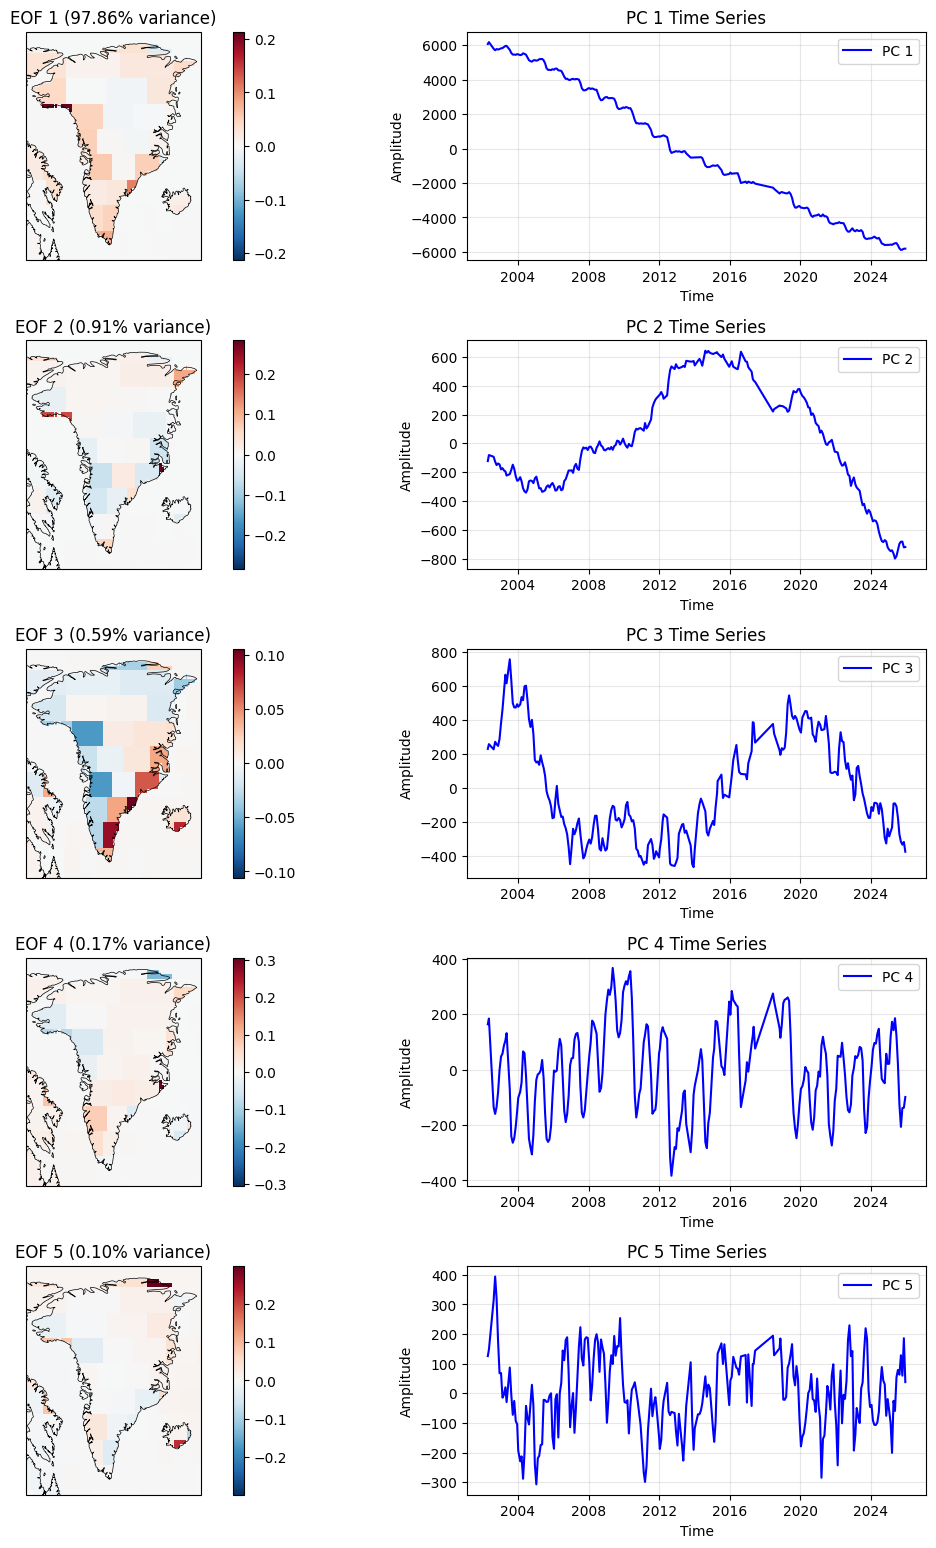

In [6]:

lon_min, lon_max = -75, -10
lat_min, lat_max = 58, 85

lon_sel = (lon_shift >= lon_min) & (lon_shift <= lon_max)
lat_sel = (lat >= lat_min) & (lat <= lat_max)

lat_reg = lat[lat_sel]
lon_reg = lon_shift[lon_sel]

lwe = mascons.variables["lwe_thickness"][:]   # shape: (time, lat, lon)

fill = getattr(mascons.variables["lwe_thickness"], "_FillValue", None)

if fill is not None:
    lwe = np.ma.masked_where(lwe == fill, lwe)

# Apply longitude sorting consistently to data
lwe = lwe[:, :, sort_idx]

lwe_reg = lwe[:, lat_sel, :][:, :, lon_sel]   # shape: (T, nlat_reg, nlon_reg)

T, nlat_reg, nlon_reg = lwe_reg.shape
X = lwe_reg.reshape(T, nlat_reg * nlon_reg)

valid_space = ~np.ma.getmaskarray(X).any(axis=0)
X_valid = X[:, valid_space]

X_anom = X_valid - X_valid.mean(axis=0)

weights_lat = np.sqrt(np.cos(np.deg2rad(lat_reg)))              # (nlat_reg,)
W_2d = np.repeat(weights_lat[:, None], nlon_reg, axis=1)       # (nlat_reg, nlon_reg)
W_full = W_2d.reshape(nlat_reg * nlon_reg)                     # (nlat_reg*nlon_reg,)
W_valid = W_full[valid_space]                                  # (Nvalid,)

X_eof = X_anom  * W_valid[None, :]

pca = PCA(n_components=5)
pca.fit(X_eof)

transformed_data = pca.transform(X_eof)
explained_variance = pca.explained_variance_ratio_

Lon2D_reg, Lat2D_reg = np.meshgrid(lon_reg, lat_reg)

N = 5

fig = plt.figure(figsize=(16, 3.8 * N))
gs = gridspec.GridSpec(N, 2, width_ratios=[1.4, 1.0], hspace=0.35, wspace=0.25)

for i in range(N):
    # Reconstruct EOF pattern on the regional grid
    full_pattern = np.full(nlat_reg * nlon_reg, np.nan)
    full_pattern[valid_space] = pca.components_[i] / W_valid
    eof_pattern = full_pattern.reshape(nlat_reg, nlon_reg)

    v = np.nanmax(np.abs(eof_pattern))

    # ---- EOF map ----
    ax_map = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    mesh = ax_map.pcolormesh(
        Lon2D_reg, Lat2D_reg, eof_pattern,
        cmap="RdBu_r",
        vmin=-v, vmax=v,
        shading="auto"
    )

    ax_map.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax_map.coastlines(linewidth=0.5)
    
    ax_map.set_xlim(lon_min, lon_max)
    ax_map.set_ylim(lat_min, lat_max)
    ax_map.set_aspect(1/np.cos(np.deg2rad(lat_reg.mean())))
    ax_map.set_xlabel("Longitude (deg)")
    ax_map.set_ylabel("Latitude (deg)")
    ax_map.set_title(f"EOF {i+1} ({explained_variance[i]*100:.2f}% variance)")
    fig.colorbar(mesh, ax=ax_map)

    # ---- PC time series ----
    ax_ts = fig.add_subplot(gs[i, 1])
    ax_ts.plot(dates_py, transformed_data[:, i], color="b", label=f"PC {i+1}")
    ax_ts.set_title(f"PC {i+1} Time Series")
    ax_ts.set_xlabel("Time")
    ax_ts.set_ylabel("Amplitude")
    ax_ts.grid(True, alpha=0.3)
    ax_ts.legend()

#plt.tight_layout()
plt.savefig("eof_results_greenland.png", dpi=500, bbox_inches="tight")
plt.show()
